### Why we need the evaluation 
Evaluating a model is the most critical step in the development process to ensure its **alignment with reality.** Contrary to intuition, achieving 100% efficiency is not ideal, as it often indicates that the model has become **biased toward the training data—a** phenomenon known as **Overfitting**. Evaluation methods vary depending on the data's nature and the model's architecture; a metric that is highly effective for one dataset might fail significantly with another. Therefore, it is essential to analyze the characteristics of each metric to ensure it is applied in **the appropriate context**.

In [31]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

In [32]:
import sys
sys.path.append("..")
from utils import gradientDescent,MAE,MSE


### Mean Absolute Error (MAE)
Mean Absolute Error (MAE) : is a straightforward metric that calculates the average of the **absolute** differences between **predicted** and **actual values**. One of its primary advantages is that the result is expressed in **the same units as the original data**, making it intuitively easy for humans to understand as a **'margin of error.'** For example, if a house is predicted to cost $100k but its actual price is $110k, we can simply say the error is $10k. Perhaps its most significant feature regarding data nature is its high resistance to **outliers**, as it treats all errors linearly without any amplification (unlike squared error metrics).
$$ MAE= \frac{1}{m} \sum_{i=1}^{m}(|y-\widehat{y}|)$$

### Mean Squared Error (MSE)
Mean Squared Error (MSE) follows a logic similar to MAE but **squares the differences before averaging**. This mathematical choice makes the metric **highly sensitive to outliers**, acting as an analytical lens that defines the model's behavior: it shows high tolerance for small errors (as squaring a fraction makes it smaller) but is extremely **aggressive** toward large errors. This '**quadratic penalty**' forces the model to prioritize reducing significant deviations over minor ones. However, a major drawback is that squaring the results causes them to lose their direct connection to the original data units, making it **less intuitive** for human interpretation.
$$ MSE= \frac{1}{m} \sum_{i=1}^{m}(y-\widehat{y})^{2}$$

In [33]:
#gearte random data to test MSE , MAE
np.random.seed(1)
simpl_size = 1000
X = np.random.random(simpl_size)*10
#the true weights
W = np.array([0.4,4])

X_with_bias = np.c_[X,np.ones(shape=(simpl_size,1))] # we add the bias term to the input data
noise = np.random.random(simpl_size) # we add some noise to the data

y = np.dot(X_with_bias,W) + noise



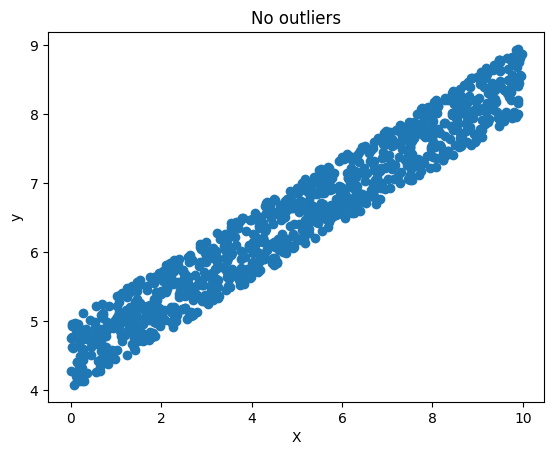

In [34]:
def plot_scater(X,y,title,xlabel,ylabel):
    plt.scatter(X,y)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("No outliers")
    plt.show()

plot_scater(X, y, title="No outliers", xlabel="X", ylabel="y")


In [35]:
#spliting data into train and test sets

train_size = int(0.8*simpl_size)
X_train_no_outliers = X[:train_size]
y_train_no_outliers = y[:train_size]
X_test_no_outliers = X_with_bias[train_size:] # we need to add the bias term to the test set as well
y_test_no_outliers = y[train_size:]
w_trained_no_outliers= gradientDescent(X_train_no_outliers,y_train_no_outliers ,learning_rate=0.01,epochs=1000)
print("Trained weights : ",w_trained_no_outliers)
y_pred = np.dot(X_test_no_outliers,w_trained_no_outliers)
print("no outliers - MSE : ",MSE(y_test_no_outliers,y_pred))
print("no outliers - MAE : ",MAE(y_test_no_outliers,y_pred))



Trained weights :  [0.46040063 4.11928088]
no outliers - MSE :  0.11981702231327769
no outliers - MAE :  0.2901469482576337


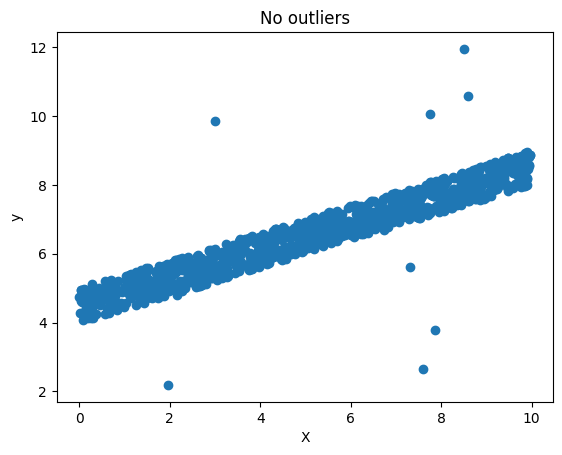

In [36]:
rng =np.random.default_rng(seed=1)
outliers = np.random.choice(simpl_size, size=10, replace=False)
y_with_outliers = y.copy()
y_with_outliers[outliers] += rng.integers(low=-5, high=5, size=10) # adding outliers to the data
plot_scater(X, y_with_outliers, title="With outliers", xlabel="X", ylabel="y")

In [37]:
X_train_with_outliers = X[:train_size]
y_train_with_outliers = y_with_outliers[:train_size]
X_test_with_outliers = X_with_bias[train_size:] # we need to add the bias term to the test set as well
y_test_with_outliers = y_with_outliers[train_size:]
w_trained_with_outliers = gradientDescent(X_train_with_outliers,y_train_with_outliers ,learning_rate=0.01,epochs=1000)
print("Trained weights : ",w_trained_with_outliers)
y_pred = np.dot(X_test_with_outliers,w_trained_with_outliers)
print("with outliers - MSE : ",MSE(y_test_with_outliers,y_pred))
print("with outliers - MAE : ",MAE(y_test_with_outliers,y_pred))

Trained weights :  [0.4603368  4.11470753]
with outliers - MSE :  0.14817230599247877
with outliers - MAE :  0.301209092776163


**Empirical Observation:**  

The results clearly demonstrate the difference in sensitivity between MSE and MAE. When outliers were introduced, **MSE increased by approximately 24%**, highlighting its aggressive penalty for large deviations. Conversely, **MAE only increased by about 3.8%**, proving its robustness and stability in the presence of noise. This confirms that while MSE is useful for training models to avoid large errors, MAE provides a more stable reflection of the average error magnitude.